# SCA with dimension sorting: demo on center-out reaching dataset

This notebook demonstrates Sparse Component Analysis (SCA) and different dimension sorting methods using a center-out reaching dataset. We first fit SCA and then demonstrate 3 different ways dimensions can be automatically sorted within our code package.

Data are trial-averaged firing rates of individual neurons collected from motor cortex (primary motor and dorsal premotor) of a non-human primate.

For this task, the monkey began each trial by touching a central touch-point. A peripheral target was shown, and after a variable, unpredictable delay period, a go cue was delivered. After capturing the peripheral target, the monkey recieved a juice reward, and returned his hand to the touch-point to begin the next trial (see [Lara et al., 2018](https://pubmed.ncbi.nlm.nih.gov/30132759/))

Data have been aligned to target onset, outward movement onset, and return reach onset.

'data' is a Condition x Neuron x Time tensor of trial-averaged firing rates.

## Import various packages

In [1]:
import numpy as np
from scipy import io

import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt

from sca.models import SCA, WeightedPCA
from sca.util import get_sample_weights, get_accuracy
from plotly.subplots import make_subplots

## local path to the directory
    - fill in the path to whererever you've saved 'datasets'

In [ ]:
# local_path = ## FILL IN PATH ##

local_path = '../datasets/'

## load data

In [3]:
data=io.loadmat(local_path + 'monkeyB_reaching.mat')

# pull out the PSTHs
# data is a C x N x T tensor 
data_array=data['data']

## Preprocess data
We're going to perform two standard (to this dataset) pre-processing steps:

   1. soft-normalize the rates (firing rate range across all conditions and times + 5)
        This step has the effect of preventing the recovered factors from being dominated by a few high firing-rate neurons while also minimizing the impact of very low firing rate neurons

   2. subtract off the cross-condition mean
        The largest signal (in terms of variance) in motor cortex during reaching is a condition-invariant 'trigger signal' (see [Kaufman et al., 2016](https://pubmed.ncbi.nlm.nih.gov/27761519/) for further discussion).
        Because we are often more interested in the condition-specific signals, we typically subtract off this trigger signal.


In [4]:
#Downsample data to speed up SCA (using a factor of 10 here)
data_downsamp=data_array[:,:,np.arange(0,data_array.shape[2],10)]

# pull out some useful numbers
numConds,numN,trlDur = np.shape(data_downsamp)

#Concatenate all the conditions (so the matrix is size N x TC instead of C x N x T)
data_concat=data_downsamp.swapaxes(0,1).reshape([data_downsamp.shape[1],data_downsamp.shape[0]*data_downsamp.shape[2]])

#fr range
fr_range=np.ptp(data_concat,axis=1)[:,None]

# make a time mask
timeMask = np.tile(np.arange(trlDur),(1,numConds)).T.flatten()

# define the times we want to use for sca/pca
# target on: 20
# move on:   77
# return:    200
trainTimes = np.arange(20,230)

# define a 'training mask' for convenience 
trainMask = np.in1d(timeMask,trainTimes)

#Subtract cross-condition mean
data_scm=data_downsamp-np.mean(data_downsamp,axis=0)[None,:,:]

#Concatenate all the conditions (so the matrix is size N x TC instead of C x N x T)
data_scm_concat=data_scm.swapaxes(0,1).reshape([data_scm.shape[1],data_scm.shape[0]*data_scm.shape[2]])

#Soft normalize (divide each neuron by its fr range + 5)
data_scm_norm=data_scm_concat/(fr_range+5)

# rename the data for convenience
#Note that model requires (T x N) input rather than (N x T), which is why there are transposes below
fit_data=np.copy(data_scm_norm.T)

# how much to weight each timestep (used by)
sample_weights=get_sample_weights(fit_data)


## Define some SCA parameters
SCA has three hyperparameters:

   number of requested factors (R_est)
   lam_orthog: determines the degree to which non-orthogonal dimensions are penalized
   lam_sparse: determines the degree to which non-sparse factors are punished.

For this analysis, we are going to use the default values for lam_orthog and lam_sparse.

Across all examined datasets, the recovered SCA factors vary litte across different hyperparameter choices

In [5]:
# number of dimensions to find
R_est=8

## Fit SCA

Using lam_sparse=  0.026214394575887204
Using lam_orthog=  146.99136801291675
Using device cpu
505.6203
3140.075


100%|██████████| 3000/3000 [00:07<00:00, 394.12it/s]


SCA R2: 0.6259894919521088


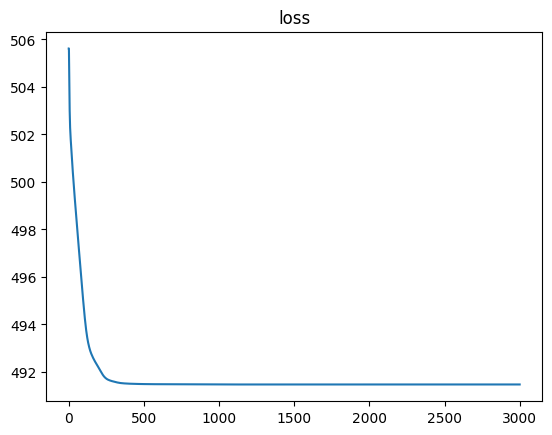

In [6]:
# fit model and 
sca = SCA(n_components=R_est)
sca.fit(X=fit_data[trainMask,:],sample_weight = sample_weights[trainMask])
sca_latent = sca.transform(fit_data)
# plot loss
plt.plot(sca.losses);
plt.title('loss');

# display fraction of total variance explained by the SCA factors
print('SCA R2: ' + str(sca.r2_score))

## Visualizing all three sorting rules

The `sort_dims()` function supports three different sorting rules:

1. **"activity"**: Order by total activity (sum of squared latents). Most active dimensions first.
   - Requires X shape: [n_time, n_neurons]

2. **"condition-time"**: Order by time of peak across-condition variance. Useful for multi-condition experiments.
   - Requires X shape: [n_time_per_condition, n_conditions, n_neurons]
   - For each dimension, finds when across-condition variance is highest
   - Orders dimensions by this peak time (earliest first)

3. **"time"**: Order by peak activity timing. Earliest peaks first.
   - Requires X shape: [n_time, n_neurons]
   - *Note: Less useful for this dataset with clear multi-condition structure*

In [7]:
# define color map and time points for plotting
cMap  = ['#5e0044', '#6f144e', '#812858', '#933c62', '#a5506d', '#b76477', '#c97881', '#db8c8c']
tgt_idx=20
move_idx=77
ret_idx=200

from sca.util import sort_dims

### Unsorted

In [8]:
# Reshape for plotting
rs_sca_latent = np.reshape(sca_latent, (-1, numConds, R_est), order='F')

In [9]:
# Plot all three sorting rules side by side
fig = make_subplots(
    rows=R_est, cols=1, shared_xaxes=True, vertical_spacing=0.0
)

yRange = [-1.8, 1.8]

for ii in range(R_est):
    for jj in range(numConds):
        latTrace = go.Scatter(y=rs_sca_latent[:, jj, ii], 
                              line=go.scatter.Line(color=cMap[jj], width=2.5), 
                              showlegend=False)
        fig.add_trace(latTrace, row=ii+1, col=1)

    fig.add_vline(x=tgt_idx, row=ii+1, col=1, line_color='black')
    fig.add_vline(x=move_idx, row=ii+1, col=1, line_color='black')
    fig.add_vline(x=ret_idx, row=ii+1, col=1, line_color='black')


fig.update_layout(height=600, width=600, title='SCA Unsorted',
                  title_font_color='black', paper_bgcolor='white', plot_bgcolor='white')
fig.update_yaxes(showgrid=False, zeroline=False, visible=False, range=yRange)
fig.update_xaxes(color='black', showgrid=False, zeroline=False, visible=False)
fig.update_xaxes(color='black', showgrid=False, zeroline=False,
                 ticks='outside', tickvals=[0, 50], ticktext=['0', '500'], visible=True, row=R_est)

fig.show()

### Sorted by 'activity'

In [10]:
#  Sort
sca_sorted_activity, sort_indices_activity = sort_dims(sca, fit_data, rule="activity")
print("Activity-sorted order of original indices:", sort_indices_activity)
# Apply the sorting transformation
sca_latent_activity = sca_sorted_activity.transform(fit_data)
# Reshape for plotting
rs_sca_latent_activity = np.reshape(sca_latent_activity, (-1, numConds, R_est), order='F')

Activity-sorted order of original indices: [0 1 3 6 2 4 5 7]


In [11]:
# Plot all three sorting rules side by side
fig = make_subplots(
    rows=R_est, cols=1, shared_xaxes=True, vertical_spacing=0.0
)

yRange = [-1.8, 1.8]

for ii in range(R_est):
    for jj in range(numConds):
        latTrace = go.Scatter(y=rs_sca_latent_activity[:, jj, ii], 
                              line=go.scatter.Line(color=cMap[jj], width=2.5), 
                              showlegend=False)
        fig.add_trace(latTrace, row=ii+1, col=1)

    fig.add_vline(x=tgt_idx, row=ii+1, col=1, line_color='black')
    fig.add_vline(x=move_idx, row=ii+1, col=1, line_color='black')
    fig.add_vline(x=ret_idx, row=ii+1, col=1, line_color='black')


fig.update_layout(height=600, width=600, title='SCA Sorted by activity',
                  title_font_color='black', paper_bgcolor='white', plot_bgcolor='white')
fig.update_yaxes(showgrid=False, zeroline=False, visible=False, range=yRange)
fig.update_xaxes(color='black', showgrid=False, zeroline=False, visible=False)
fig.update_xaxes(color='black', showgrid=False, zeroline=False,
                 ticks='outside', tickvals=[0, 50], ticktext=['0', '500'], visible=True, row=R_est)

fig.show()

### Sorted by 'time'

In [12]:
#  Sort
sca_sorted_time, sort_indices_time = sort_dims(sca, fit_data, rule="time")
print("Time-sorted order of original indices:", sort_indices_time)
# Apply the sorting transformation
sca_latent_time = sca_sorted_time.transform(fit_data)
# Reshape for plotting
rs_sca_latent_time = np.reshape(sca_latent_time, (-1, numConds, R_est), order='F')

Time-sorted order of original indices: [1 2 0 6 7 4 3 5]


In [13]:
# Plot all three sorting rules side by side
fig = make_subplots(
    rows=R_est, cols=1, shared_xaxes=True, vertical_spacing=0.0
)

yRange = [-1.8, 1.8]

for ii in range(R_est):
    for jj in range(numConds):
        latTrace = go.Scatter(y=rs_sca_latent_time[:, jj, ii], 
                              line=go.scatter.Line(color=cMap[jj], width=2.5), 
                              showlegend=False)
        fig.add_trace(latTrace, row=ii+1, col=1)

    fig.add_vline(x=tgt_idx, row=ii+1, col=1, line_color='black')
    fig.add_vline(x=move_idx, row=ii+1, col=1, line_color='black')
    fig.add_vline(x=ret_idx, row=ii+1, col=1, line_color='black')


fig.update_layout(height=600, width=600, title='SCA Sorted by time',
                  title_font_color='black', paper_bgcolor='white', plot_bgcolor='white')
fig.update_yaxes(showgrid=False, zeroline=False, visible=False, range=yRange)
fig.update_xaxes(color='black', showgrid=False, zeroline=False, visible=False)
fig.update_xaxes(color='black', showgrid=False, zeroline=False,
                 ticks='outside', tickvals=[0, 50], ticktext=['0', '500'], visible=True, row=R_est)

fig.show()

### Sorted by 'condition-time'

In [14]:
# Prepare 3D data for condition-time sorting
# Reshape concatenated data into [time_per_condition, n_conditions, n_neurons]
data_3d = np.reshape(fit_data, (trlDur, numConds, numN), order='F')

#  Sort
sca_sorted_condition_time, sort_indices_condition_time = sort_dims(sca, data_3d, rule="condition-time")
print("Condition-time-sorted order of original indices:", sort_indices_condition_time)
# Apply the sorting transformation
sca_latent_condition_time = sca_sorted_condition_time.transform(fit_data)
# Reshape for plotting
rs_sca_latent_condition_time = np.reshape(sca_latent_condition_time, (-1, numConds, R_est), order='F')

Condition-time-sorted order of original indices: [1 4 3 0 2 7 6 5]


In [15]:
# Plot all three sorting rules side by side
fig = make_subplots(
    rows=R_est, cols=1, shared_xaxes=True, vertical_spacing=0.0
)

yRange = [-1.8, 1.8]

for ii in range(R_est):
    for jj in range(numConds):
        latTrace = go.Scatter(y=rs_sca_latent_condition_time[:, jj, ii], 
                              line=go.scatter.Line(color=cMap[jj], width=2.5), 
                              showlegend=False)
        fig.add_trace(latTrace, row=ii+1, col=1)

    fig.add_vline(x=tgt_idx, row=ii+1, col=1, line_color='black')
    fig.add_vline(x=move_idx, row=ii+1, col=1, line_color='black')
    fig.add_vline(x=ret_idx, row=ii+1, col=1, line_color='black')


fig.update_layout(height=600, width=600, title='SCA Sorted by condition-time',
                  title_font_color='black', paper_bgcolor='white', plot_bgcolor='white')
fig.update_yaxes(showgrid=False, zeroline=False, visible=False, range=yRange)
fig.update_xaxes(color='black', showgrid=False, zeroline=False, visible=False)
fig.update_xaxes(color='black', showgrid=False, zeroline=False,
                 ticks='outside', tickvals=[0, 50], ticktext=['0', '500'], visible=True, row=R_est)

fig.show()